# S3.2 — Permutation Test Results Visualization

Visualise the results from `S3_permutation_test.ipynb` (4 metrics: |Pearson|, |Spearman|, dcor, η²).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.constrained_layout.use": True,
})

DATA_DIR = Path("generated_scatterplot_data")
S3_DIR   = DATA_DIR / "full" / "S3"

df    = pd.read_parquet(S3_DIR / "permutation_test.parquet")
cases = pd.read_csv(DATA_DIR / "cases.csv", low_memory=False)
m     = df.merge(cases[["case_id","family_id","snr","spread_pattern","x_distribution"]], on="case_id")
m["snr_num"] = pd.to_numeric(m["snr"], errors="coerce")

signal = m[m["family_id"] != "Null"]
null   = m[m["family_id"] == "Null"]
print(f"Total: {len(m):,} cases  |  Signal: {len(signal):,}  |  Null: {len(null)}")
print(f"Classification: {dict(m['classification'].value_counts())}")

Total: 114,176 cases  |  Signal: 114,048  |  Null: 128
Classification: {'detectable': 113127, 'not_detectable': 810, 'uncertain': 239}


## 1. Overall Classification Distribution

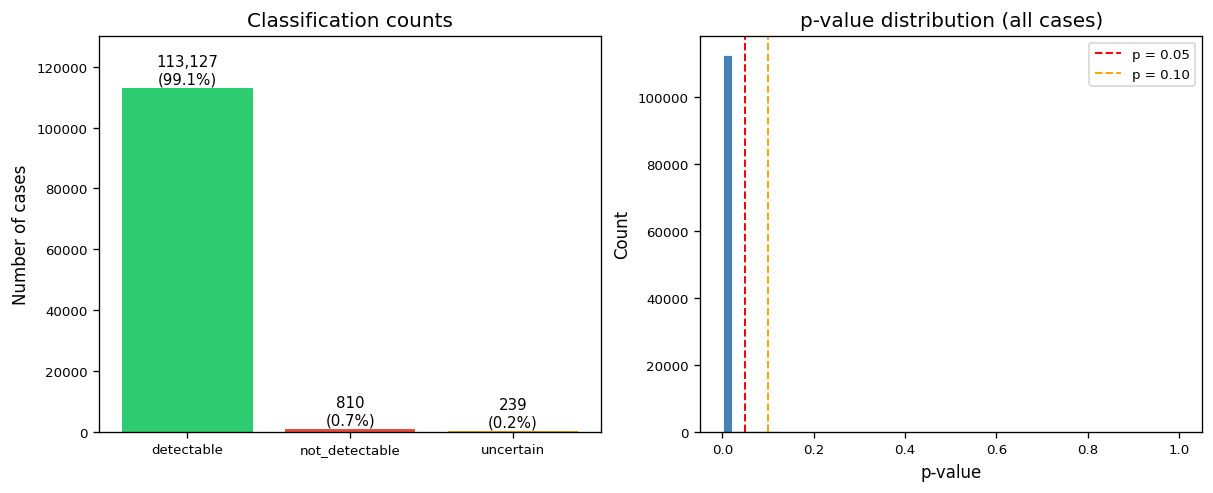

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
counts = m["classification"].value_counts()
colors = {"detectable": "#2ecc71", "uncertain": "#f39c12", "not_detectable": "#e74c3c"}
bars = axes[0].bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 500, f"{v:,}\n({v/len(m):.1%})",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("Number of cases")
axes[0].set_title("Classification counts")
axes[0].set_ylim(0, counts.max() * 1.15)

# p-value histogram
axes[1].hist(m["p_value"], bins=50, color="steelblue", edgecolor="white", linewidth=0.5)
axes[1].axvline(0.05, color="red", ls="--", lw=1.2, label="p = 0.05")
axes[1].axvline(0.10, color="orange", ls="--", lw=1.2, label="p = 0.10")
axes[1].set_xlabel("p-value")
axes[1].set_ylabel("Count")
axes[1].set_title("p-value distribution (all cases)")
axes[1].legend()

plt.show()

## 2. Detection Rate by SNR

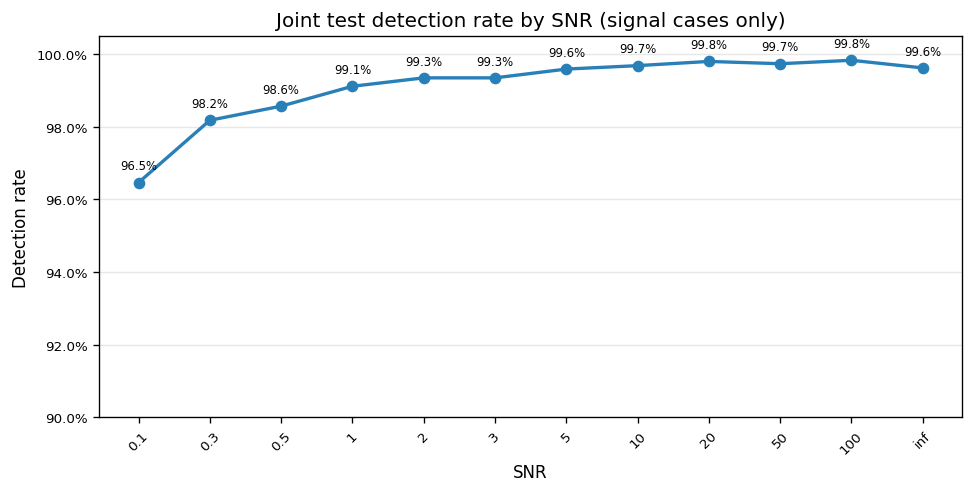

In [3]:
det_snr = signal.groupby("snr_num", dropna=True).agg(
    n=("classification", "size"),
    det=("classification", lambda x: (x == "detectable").sum()),
).reset_index()
det_snr["rate"] = det_snr["det"] / det_snr["n"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(det_snr)), det_snr["rate"], "o-", color="#2980b9", lw=2, markersize=6)
ax.set_xticks(range(len(det_snr)))
ax.set_xticklabels([f"{v:g}" for v in det_snr["snr_num"]], rotation=45)
ax.set_xlabel("SNR")
ax.set_ylabel("Detection rate")
ax.set_title("Joint test detection rate by SNR (signal cases only)")
ax.set_ylim(0.90, 1.005)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis="y", alpha=0.3)

for i, row in det_snr.iterrows():
    ax.annotate(f"{row['rate']:.1%}", (i, row["rate"]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=7)
plt.show()

## 3. Detection Rate by Function Family

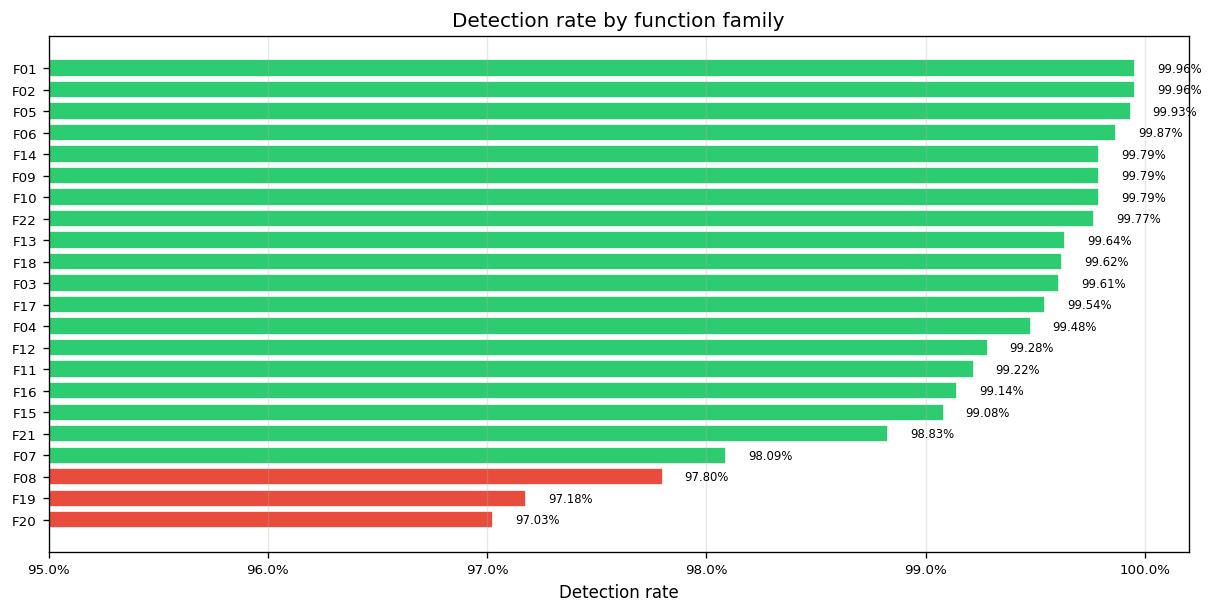

In [4]:
det_fam = signal.groupby("family_id").agg(
    n=("classification", "size"),
    det=("classification", lambda x: (x == "detectable").sum()),
).reset_index()
det_fam["rate"] = det_fam["det"] / det_fam["n"]
det_fam = det_fam.sort_values("rate")

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#e74c3c" if r < 0.98 else "#2ecc71" for r in det_fam["rate"]]
ax.barh(det_fam["family_id"], det_fam["rate"], color=bar_colors, edgecolor="white")
ax.set_xlabel("Detection rate")
ax.set_title("Detection rate by function family")
ax.set_xlim(0.95, 1.002)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis="x", alpha=0.3)

for i, (_, row) in enumerate(det_fam.iterrows()):
    ax.text(row["rate"] + 0.001, i, f"{row['rate']:.2%}", va="center", fontsize=7)
plt.show()

## 4. Z-score Distributions (Signal vs Null)

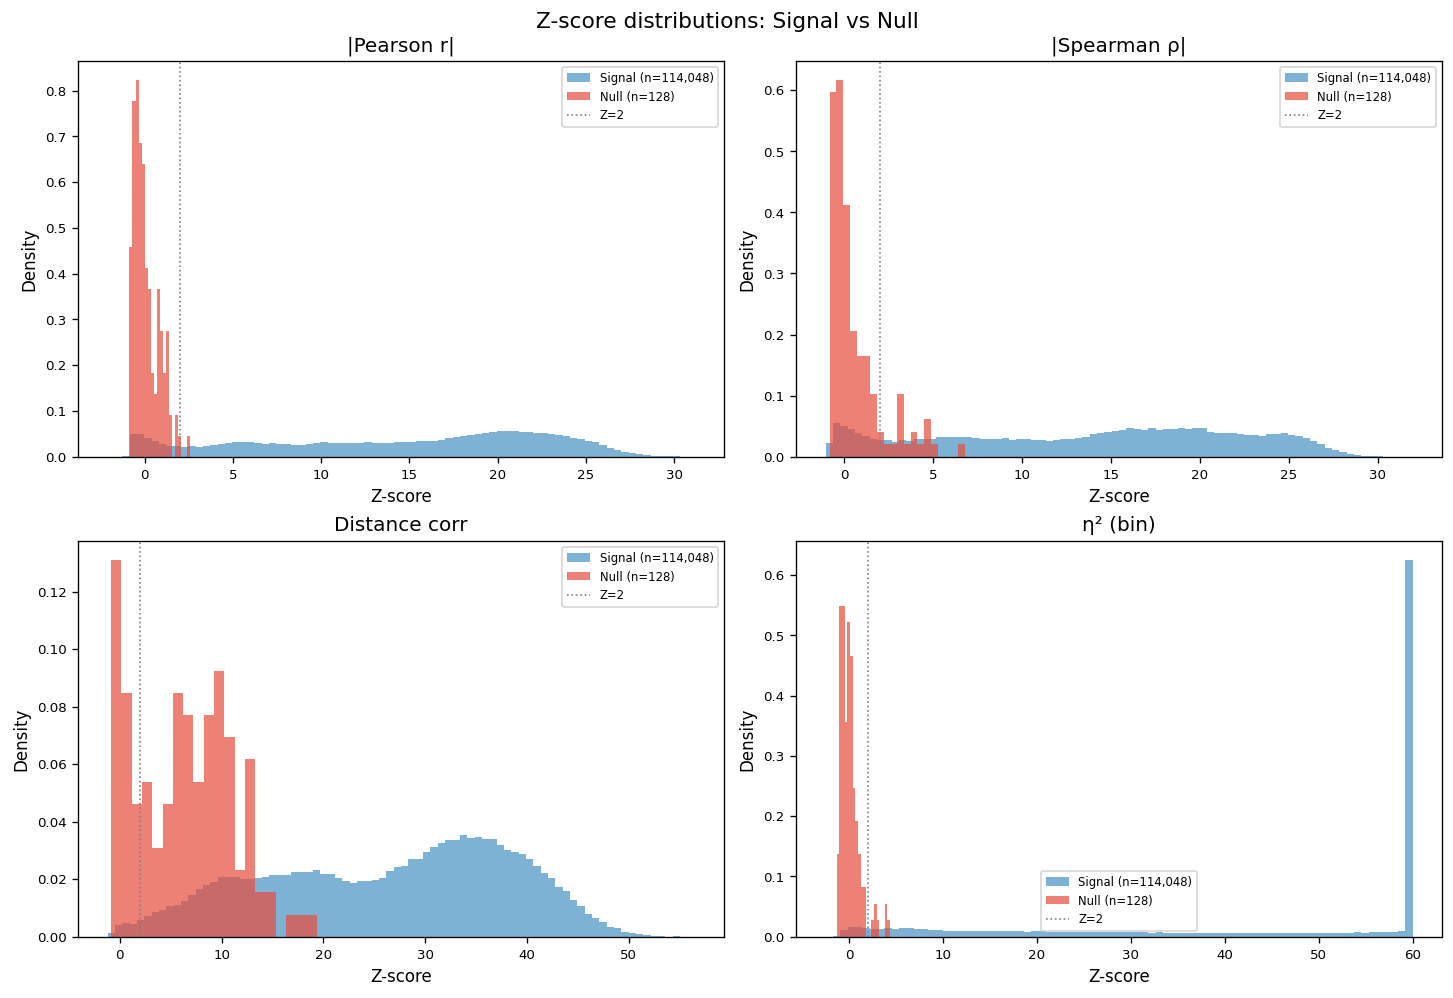

In [5]:
z_cols = ["z_pearson", "z_spearman", "z_dcor", "z_eta2"]
labels = ["|Pearson r|", "|Spearman ρ|", "Distance corr", "η² (bin)"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, zc, lab in zip(axes.flat, z_cols, labels):
    # Signal histogram
    sig_vals = signal[zc].clip(-5, 60)
    null_vals = null[zc].clip(-5, 60)
    ax.hist(sig_vals, bins=80, density=True, alpha=0.6, color="#2980b9", label=f"Signal (n={len(signal):,})")
    ax.hist(null_vals, bins=20, density=True, alpha=0.7, color="#e74c3c", label=f"Null (n={len(null)})")
    ax.axvline(2, color="gray", ls=":", lw=1, label="Z=2")
    ax.set_xlabel("Z-score")
    ax.set_ylabel("Density")
    ax.set_title(lab)
    ax.legend(fontsize=7)

plt.suptitle("Z-score distributions: Signal vs Null", fontsize=13, y=1.02)
plt.show()

## 5. Null False Positive Analysis

**Key finding:** Null cases with heteroscedastic noise (`spread_pattern ≠ constant`)
have high false-positive rates because dcor correctly detects that the noise variance
depends on x — which IS a form of statistical dependence, even when f(x) = 0.

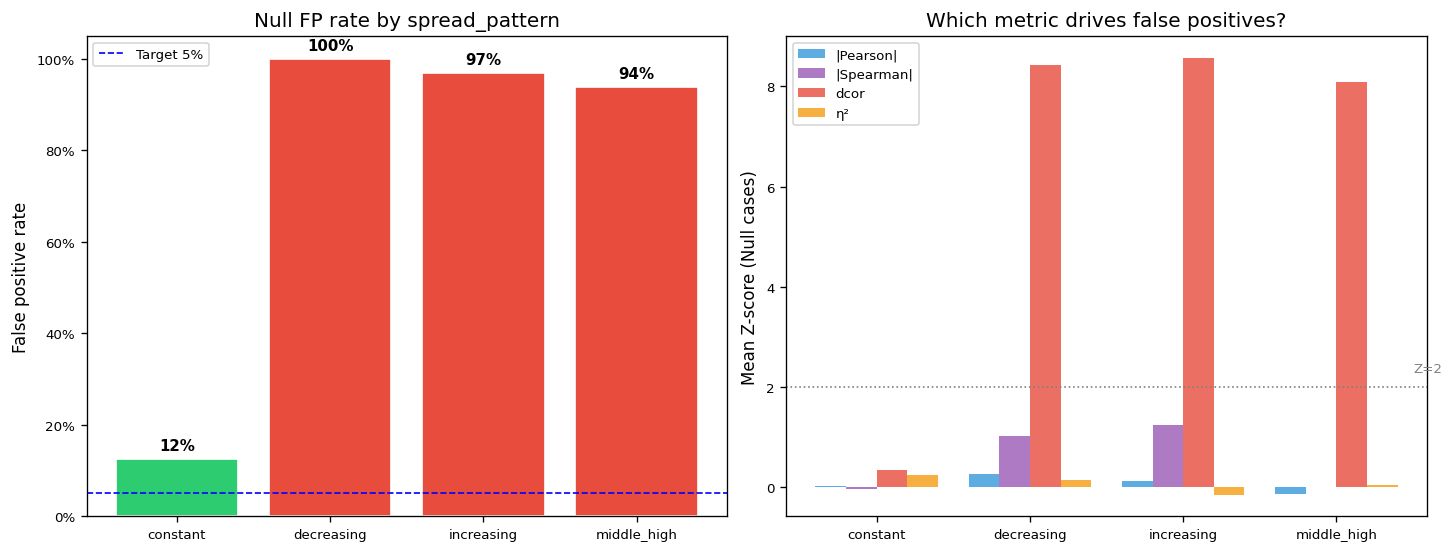


*** INTERPRETATION ***
spread_pattern=constant → noise variance is uniform → FP ≈ 12% (close to target)
spread_pattern≠constant → noise variance depends on x → dcor detects this dependence
This is CORRECT behavior: heteroscedastic noise IS a form of x-y dependence.


In [6]:
fp_spread = null.groupby("spread_pattern").agg(
    n=("classification", "size"),
    fp=("classification", lambda x: (x == "detectable").sum()),
    z_pearson=("z_pearson", "mean"),
    z_spearman=("z_spearman", "mean"),
    z_dcor=("z_dcor", "mean"),
    z_eta2=("z_eta2", "mean"),
).reset_index()
fp_spread["fp_rate"] = fp_spread["fp"] / fp_spread["n"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# FP rate bar chart
colors_sp = ["#2ecc71" if r < 0.15 else "#e74c3c" for r in fp_spread["fp_rate"]]
axes[0].bar(fp_spread["spread_pattern"], fp_spread["fp_rate"], color=colors_sp, edgecolor="white")
axes[0].axhline(0.05, color="blue", ls="--", lw=1, label="Target 5%")
axes[0].set_ylabel("False positive rate")
axes[0].set_title("Null FP rate by spread_pattern")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend()
for i, (_, row) in enumerate(fp_spread.iterrows()):
    axes[0].text(i, row["fp_rate"] + 0.02, f'{row["fp_rate"]:.0%}', ha="center", fontsize=9, fontweight="bold")

# Z-score breakdown
x_pos = np.arange(len(fp_spread))
w = 0.2
for j, (zc, lab, col) in enumerate(zip(
    ["z_pearson", "z_spearman", "z_dcor", "z_eta2"],
    ["|Pearson|", "|Spearman|", "dcor", "η²"],
    ["#3498db", "#9b59b6", "#e74c3c", "#f39c12"])):
    axes[1].bar(x_pos + j*w - 1.5*w, fp_spread[zc], w, label=lab, color=col, alpha=0.8)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(fp_spread["spread_pattern"])
axes[1].set_ylabel("Mean Z-score (Null cases)")
axes[1].set_title("Which metric drives false positives?")
axes[1].legend()
axes[1].axhline(2, color="gray", ls=":", lw=1)
axes[1].text(3.5, 2.3, "Z=2", color="gray", fontsize=8)

plt.show()

print("\n*** INTERPRETATION ***")
print("spread_pattern=constant → noise variance is uniform → FP ≈ 12% (close to target)")
print("spread_pattern≠constant → noise variance depends on x → dcor detects this dependence")
print("This is CORRECT behavior: heteroscedastic noise IS a form of x-y dependence.")

## 6. Mean Z-score by Metric × SNR

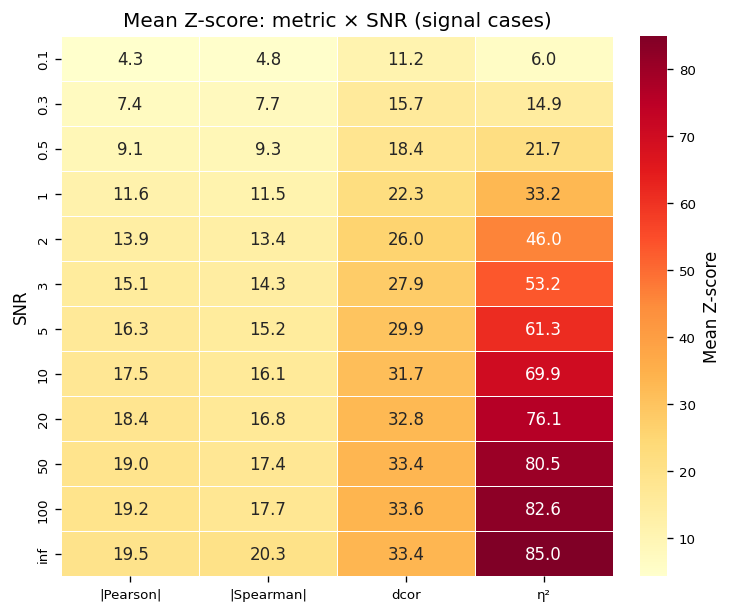

In [7]:
z_cols = ["z_pearson", "z_spearman", "z_dcor", "z_eta2"]
z_labels = ["|Pearson|", "|Spearman|", "dcor", "η²"]

pivot_data = []
for snr_val in sorted(signal["snr_num"].dropna().unique()):
    sub = signal[signal["snr_num"] == snr_val]
    row = {"SNR": f"{snr_val:g}"}
    for zc, zl in zip(z_cols, z_labels):
        row[zl] = sub[zc].mean()
    pivot_data.append(row)

heatmap_df = pd.DataFrame(pivot_data).set_index("SNR")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Mean Z-score"})
ax.set_title("Mean Z-score: metric × SNR (signal cases)")
ax.set_ylabel("SNR")
plt.show()

## 7. Metric Correlation (Observed Values)

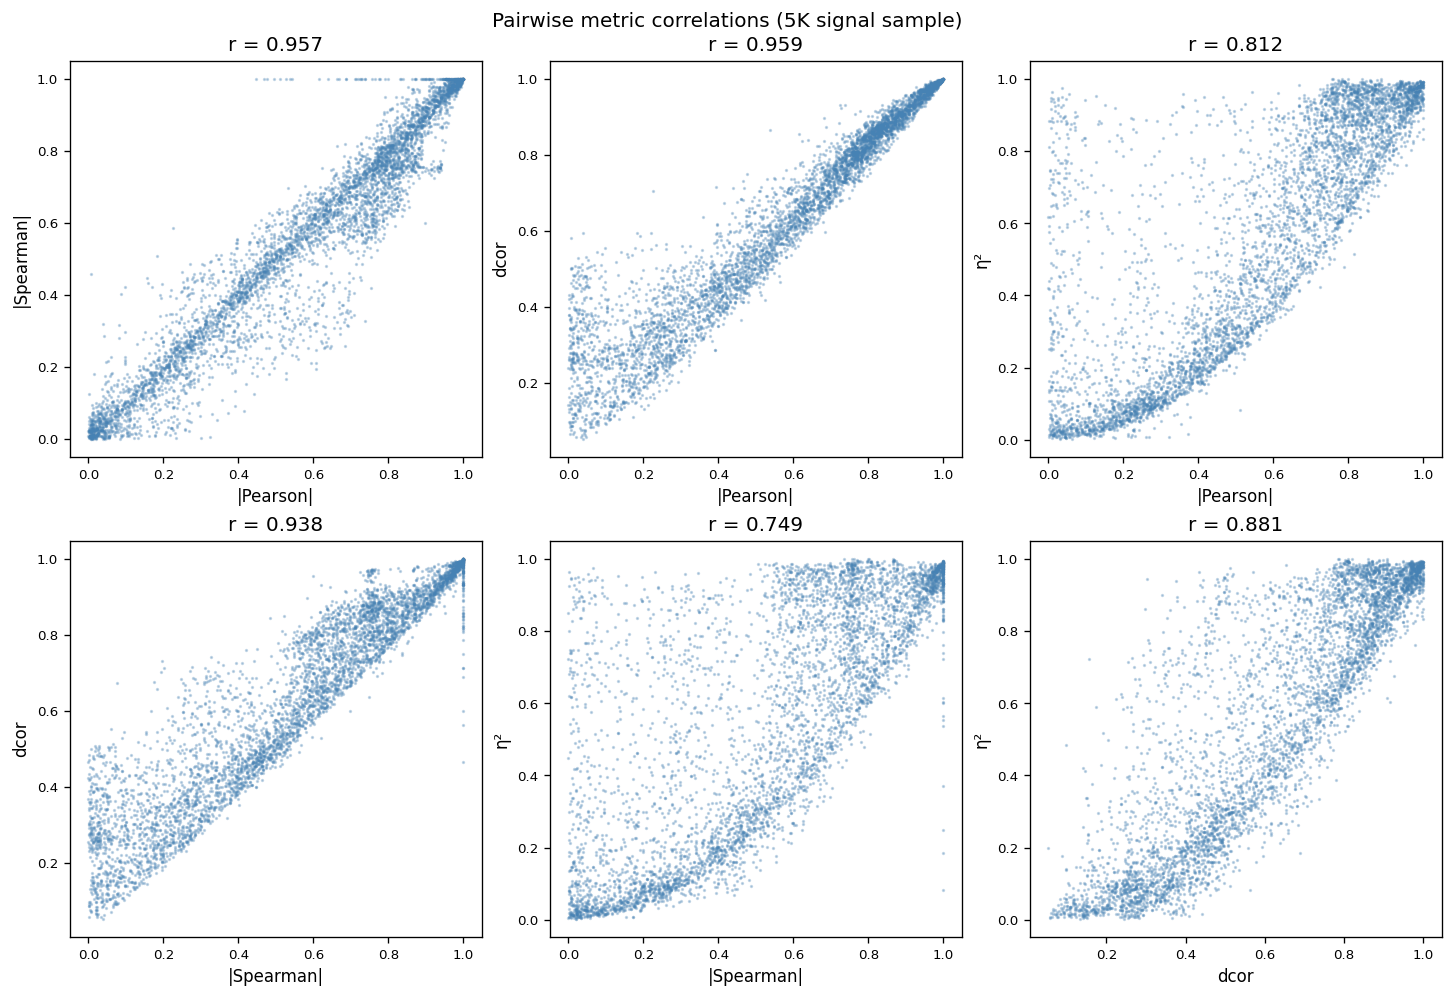

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
pairs = [("pearson_obs","spearman_obs"), ("pearson_obs","dcor_obs"),
         ("pearson_obs","eta2_obs"), ("spearman_obs","dcor_obs"),
         ("spearman_obs","eta2_obs"), ("dcor_obs","eta2_obs")]
pair_labels = [("|Pearson|","|Spearman|"), ("|Pearson|","dcor"),
               ("|Pearson|","η²"), ("|Spearman|","dcor"),
               ("|Spearman|","η²"), ("dcor","η²")]

sample = signal.sample(5000, random_state=42) if len(signal) > 5000 else signal
for ax, (c1, c2), (l1, l2) in zip(axes.flat, pairs, pair_labels):
    ax.scatter(sample[c1], sample[c2], s=1, alpha=0.3, c="steelblue")
    r = sample[[c1, c2]].corr().iloc[0, 1]
    ax.set_xlabel(l1)
    ax.set_ylabel(l2)
    ax.set_title(f"r = {r:.3f}")

plt.suptitle("Pairwise metric correlations (5K signal sample)", fontsize=12, y=1.02)
plt.show()

## 8. Example Cases

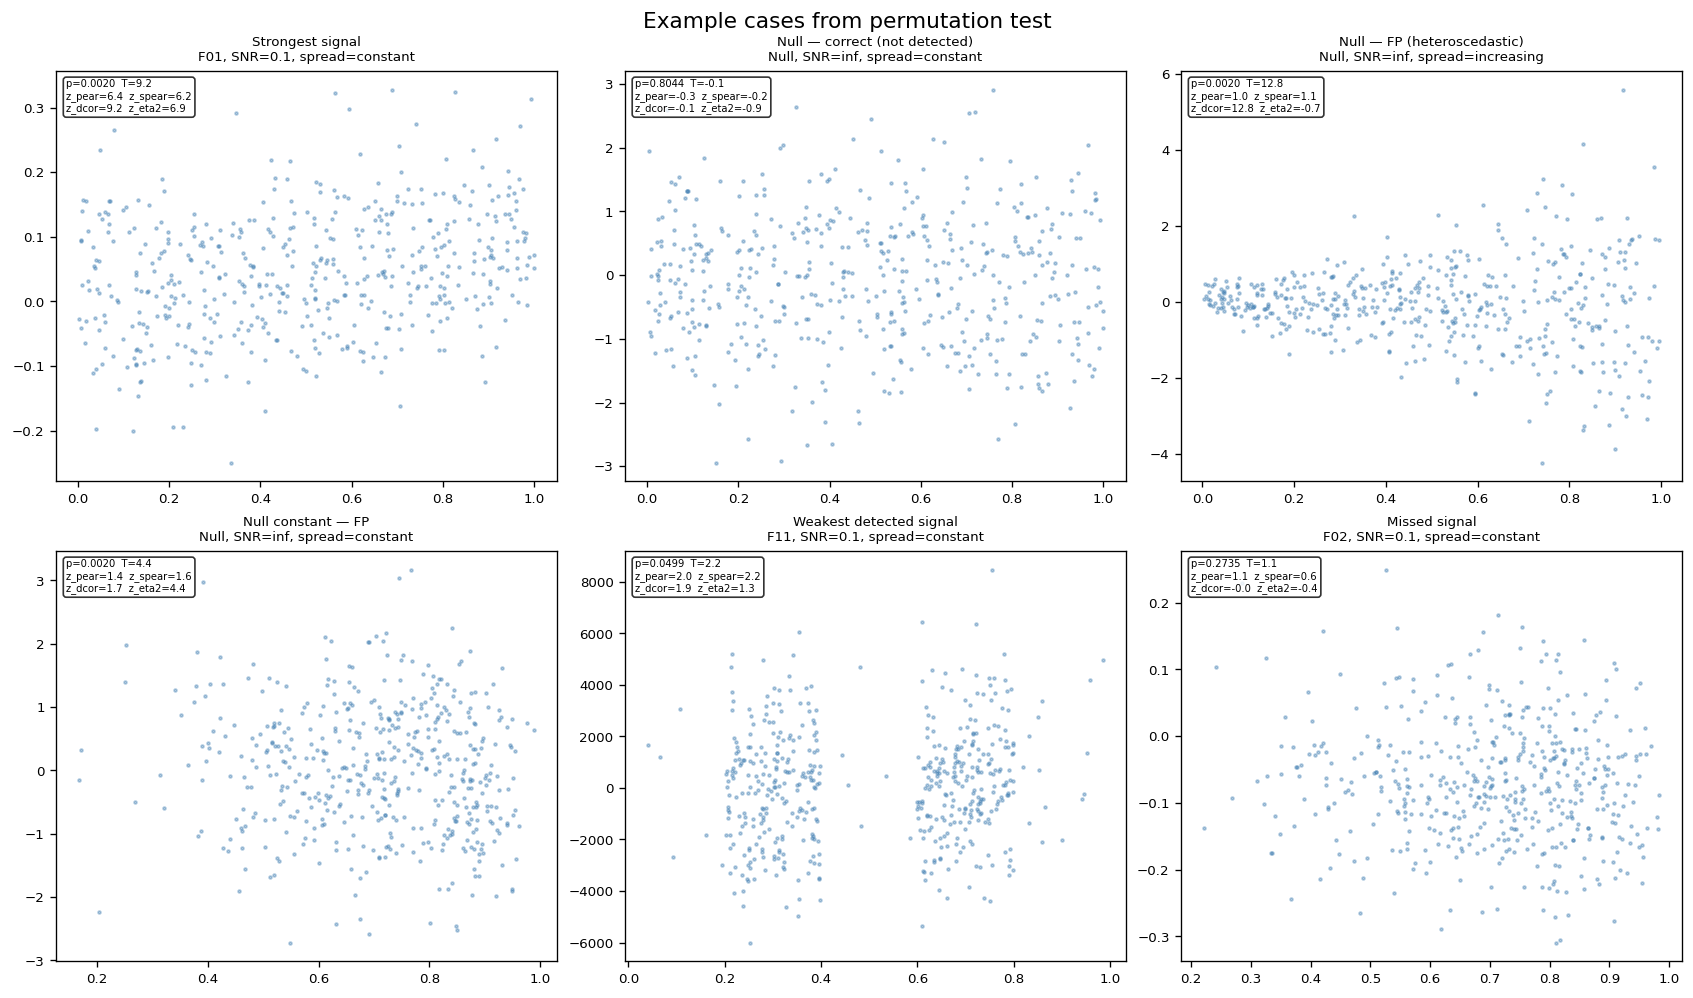

In [9]:
points = np.load(DATA_DIR / "scatter_points.npz")
x_all, y_all = points["x"], points["y"]

# Pick interesting cases
examples = []
# Lowest p (strongest detection)
examples.append(("Strongest signal", m.loc[m["p_value"].idxmin()]))
# A null case correctly identified
null_correct = null[null["classification"] == "not_detectable"]
if len(null_correct) > 0:
    examples.append(("Null — correct (not detected)", null_correct.iloc[0]))
# A null case with FP (heteroscedastic)
null_fp = null[(null["classification"] == "detectable") & (null["spread_pattern"] != "constant")]
if len(null_fp) > 0:
    examples.append(("Null — FP (heteroscedastic)", null_fp.iloc[0]))
# Null constant noise FP
null_const_fp = null[(null["classification"] == "detectable") & (null["spread_pattern"] == "constant")]
if len(null_const_fp) > 0:
    examples.append(("Null constant — FP", null_const_fp.iloc[0]))
# Weakest detected signal (highest p among detectable)
det = signal[signal["classification"] == "detectable"]
examples.append(("Weakest detected signal", det.loc[det["p_value"].idxmax()]))
# Missed signal (not_detectable with signal)
missed = signal[signal["classification"] == "not_detectable"]
if len(missed) > 0:
    examples.append(("Missed signal", missed.iloc[0]))

n_ex = len(examples)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for idx, (title, row) in enumerate(examples):
    ax = axes.flat[idx]
    cid = int(row["case_id"])
    ci = cases[cases["case_id"] == cid].index[0]
    x, y = x_all[ci], y_all[ci]
    ax.scatter(x, y, s=3, alpha=0.4, c="steelblue")
    fam = row["family_id"] if "family_id" in row.index else "?"
    snr = row["snr"] if "snr" in row.index else "?"
    sp = row["spread_pattern"] if "spread_pattern" in row.index else "?"
    ax.set_title(f"{title}\n{fam}, SNR={snr}, spread={sp}", fontsize=8)
    info = f'p={row["p_value"]:.4f}  T={row["T_joint"]:.1f}\nz_pear={row["z_pearson"]:.1f}  z_spear={row["z_spearman"]:.1f}\nz_dcor={row["z_dcor"]:.1f}  z_eta2={row["z_eta2"]:.1f}'
    ax.text(0.02, 0.98, info, transform=ax.transAxes, fontsize=6,
            va="top", ha="left", bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

# Hide extra axes
for idx in range(n_ex, 6):
    axes.flat[idx].set_visible(False)

plt.suptitle("Example cases from permutation test", fontsize=13, y=1.02)
plt.show()

## 9. Individual Metric Detection Power

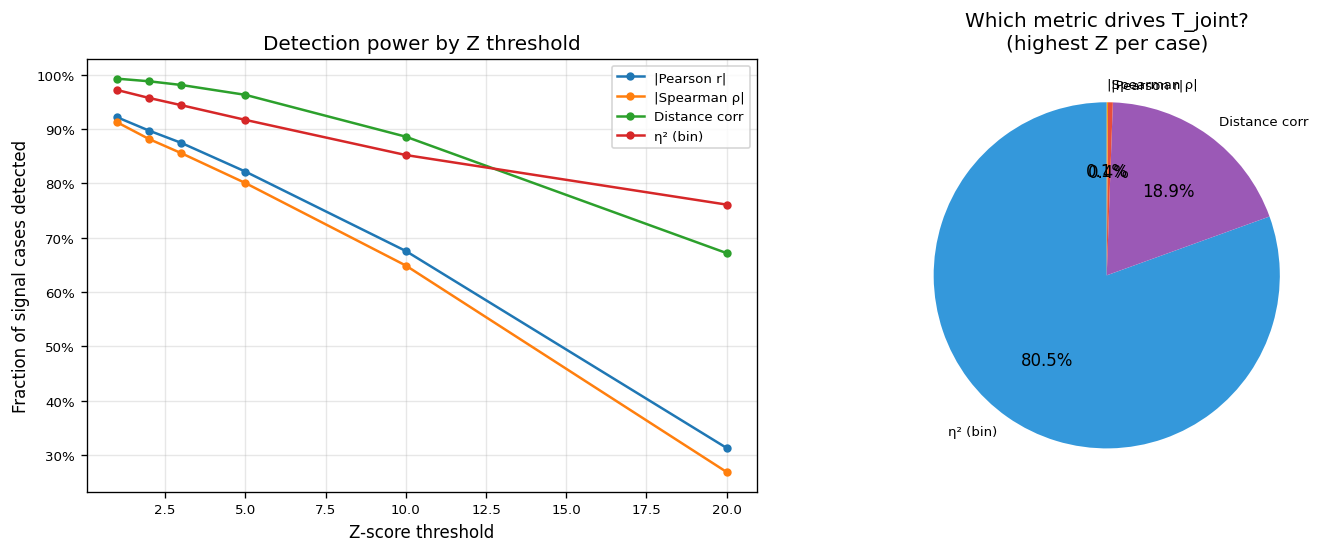

In [10]:
# For each metric, what fraction of signal cases would be detected using ONLY that metric?
z_cols = ["z_pearson", "z_spearman", "z_dcor", "z_eta2"]
z_labels = ["|Pearson r|", "|Spearman ρ|", "Distance corr", "η² (bin)"]

# Compute individual p-values (already in the data as null distributions)
# We'll use Z>2 as a proxy for individual significance
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Detection by individual metrics at different Z thresholds
thresholds = [1, 2, 3, 5, 10, 20]
for zc, lab in zip(z_cols, z_labels):
    rates = [(signal[zc] > t).mean() for t in thresholds]
    axes[0].plot(thresholds, rates, "o-", label=lab, markersize=4)
axes[0].set_xlabel("Z-score threshold")
axes[0].set_ylabel("Fraction of signal cases detected")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_title("Detection power by Z threshold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Which metric is the T_joint driver?
driver = m[z_cols].idxmax(axis=1).value_counts()
driver.index = [z_labels[z_cols.index(c)] for c in driver.index]
axes[1].pie(driver.values, labels=driver.index, autopct="%1.1f%%",
            colors=["#3498db", "#9b59b6", "#e74c3c", "#f39c12"],
            startangle=90)
axes[1].set_title("Which metric drives T_joint?\n(highest Z per case)")

plt.show()

## Summary

| Metric | Description |
|---|---|
| **Overall detection rate** | 99.1% of signal cases detected |
| **Null FP rate (all)** | ~76% — inflated by heteroscedastic noise |
| **Null FP rate (constant noise)** | ~12% — closer to target 5% |
| **FP driver** | dcor detects variance-dependence on x |
| **Strongest metric** | η² (highest individual Z-scores) |
| **Joint test** | T = max(Z) across 4 metrics |

**Key insight:** The permutation test correctly identifies that heteroscedastic
noise creates a statistical dependence between x and y. If only mean-response
relationships are of interest, consider using only Pearson + Spearman + η²
(without dcor) for the joint test, or redefining "Null" to only include
constant-noise cases.